# 03 — XAI Analysis

Apply and compare XAI methods (HiResCAM, GradCAM, GradientSHAP, KernelSHAP) on individual ECG samples and evaluate faithfulness using deletion curves (AOPC).

In [9]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import torch
import yaml

from src.models.cnn import load_model, get_layer, print_layers
from src.data.dataset import ArrhythmiaDataset, ARRHYTHMIA_CLASSES
from src.explainability.captum_methods import (
    compute_gradient_shap,
)
from src.explainability.kernel_shap import compute_kernel_shap
from src.explainability.gradcam import compute_hirescam, compute_gradcam
from src.explainability.evaluation import compare_methods, insertion_curve, deletion_curve, aggregate_aopc
from src.visualization.plots import (
    plot_method_comparison, plot_deletion_curves,
    plot_faithfulness_curves, plot_aggregate_aopc,
)

with open('../configs/model.yaml') as f:
    model_cfg = yaml.safe_load(f)
with open('../configs/data.yaml') as f:
    data_cfg = yaml.safe_load(f)
with open('../configs/xai.yaml') as f:
    xai_cfg = yaml.safe_load(f)

DATA_DIR = '../' + data_cfg['dataset']['raw_dir']
FS = data_cfg['signal']['sample_rate']
WEIGHTS = '../' + model_cfg['model']['trained_weights']
TARGET_LAYER = model_cfg['model']['target_layer']
CLASSES = data_cfg['labels']['classes']
SEED = data_cfg['splits']['seed']
print(f"Classes: {CLASSES}")
print(f"Target layer: {TARGET_LAYER}")

Classes: ['SB', 'SR', 'AF', 'ST', 'TWC']
Target layer: 7.2.convpath.1.0


## Load model and pick a sample

CAM-based methods (GradCAM, HiResCAM) produce attributions from a specific convolutional layer's activations. We target the **last convolutional layer** because it captures the highest-level learned features while still retaining temporal (spatial) resolution — earlier layers would highlight low-level patterns (edges, slopes) rather than diagnostically meaningful waveform segments.

In [2]:
model = load_model(
    WEIGHTS,
    n_leads=model_cfg['model']['n_leads'],
    n_classes=model_cfg['model']['n_classes'],
    variant=model_cfg['model']['name'],
)
model.eval()
print_layers(model)

target_layer = get_layer(model, TARGET_LAYER)
print(f"\nTarget layer '{TARGET_LAYER}' -> {target_layer.__class__.__name__}")

                                                              XResNet
0                                                             ConvLayer
0.0                                                           Conv1d
0.1                                                           BatchNorm1d
0.2                                                           ReLU
1                                                             ConvLayer
1.0                                                           Conv1d
1.1                                                           BatchNorm1d
1.2                                                           ReLU
2                                                             ConvLayer
2.0                                                           Conv1d
2.1                                                           BatchNorm1d
2.2                                                           ReLU
3                                                             MaxPool1d
4           

## Load a sample record and pick a target class

We use **atrial fibrillation (AF)** as the target class because it has clinically well-known ECG signatures — irregular R-R intervals and absent P-waves — making it a good candidate for validating whether the XAI methods highlight medically meaningful regions of the signal.

In [3]:
cache_dir = f'../data/preprocessed/{FS}'
dataset = ArrhythmiaDataset(
    DATA_DIR, split='test', classes=CLASSES, seed=SEED,
    cache_dir=cache_dir, sampling_rate=FS,
    metadata_path='../data/processed/arrhythmia_metadata.csv',
)

# Find a sample with AFIB label
target_class_name = 'AF'
target_class = CLASSES.index(target_class_name)

for i in range(len(dataset)):
    sig, lab = dataset[i]
    if lab[target_class] == 1.0:
        signal = sig.unsqueeze(0)  # [1, 12, 5000]
        print(f"Sample index: {i}")
        print(f"Labels: {[CLASSES[j] for j in range(len(lab)) if lab[j] == 1.0]}")
        print(f"Target class: {target_class_name} (index {target_class})")
        print(f"Signal shape: {signal.shape}")
        break

Skipping 1 records with missing .npy cache files
Sample index: 4
Labels: ['AF']
Target class: AF (index 2)
Signal shape: torch.Size([1, 12, 5000])


### Attribution methods

We compare four XAI methods that fall into two families:

- **Gradient-based (GradCAM, HiResCAM):** use the gradient of the target class w.r.t. a convolutional layer's activations. Fast to compute, but produce a single 1D attribution vector (shared across leads) because the conv layer already aggregates lead information.
- **SHAP-based (GradientSHAP, KernelSHAP):** estimate Shapley values that measure each feature's marginal contribution. Model-agnostic and produce **per-lead** attributions, but require a baseline (reference input).

The **zero baseline** represents "no signal" — a neutral reference point. Each feature's attribution then measures how much its presence (vs. absence) shifts the model's prediction.

In [4]:
# Background tensor for SHAP-based methods — 20 zero-valued reference signals
background = torch.zeros(20, 12, signal.shape[-1])

n_samples = xai_cfg['methods']['gradient_shap']['n_samples']
ks_n_segments = xai_cfg['methods']['kernel_shap']['n_segments']
ks_nsamples = xai_cfg['methods']['kernel_shap']['nsamples']

gs_attr = compute_gradient_shap(model, signal, target_class, background, n_samples=n_samples)
ks_attr = compute_kernel_shap(model, signal, target_class, background,
                              n_segments=ks_n_segments, nsamples=ks_nsamples)
hrc_attr = compute_hirescam(model, signal, target_layer, target_class)
gc_attr = compute_gradcam(model, signal, target_layer, target_class)

print("Attribution shapes ([12, 5000] for Captum/KernelSHAP, [5000] for CAM):")
for name, attr in [('GradientSHAP', gs_attr), ('KernelSHAP', ks_attr),
                   ('HiResCAM', hrc_attr), ('GradCAM', gc_attr)]:
    print(f"{name:<15} {attr.shape}")


Attribution shapes ([12, 5000] for Captum/KernelSHAP, [5000] for CAM):
GradientSHAP    (12, 5000)
KernelSHAP      (12, 5000)
HiResCAM        (5000,)
GradCAM         (5000,)


## SHAP visualisations

Three complementary views of the SHAP attributions:

1. **Segment-level bar plot** — temporal importance at a glance: which time windows matter most for the AF prediction.
2. **Per-lead importance** — identifies which of the 12 leads contribute most, useful for understanding the model's spatial focus.
3. **Lead × time heatmap** — reveals interactions across leads and time, showing whether important regions align across leads or are lead-specific.

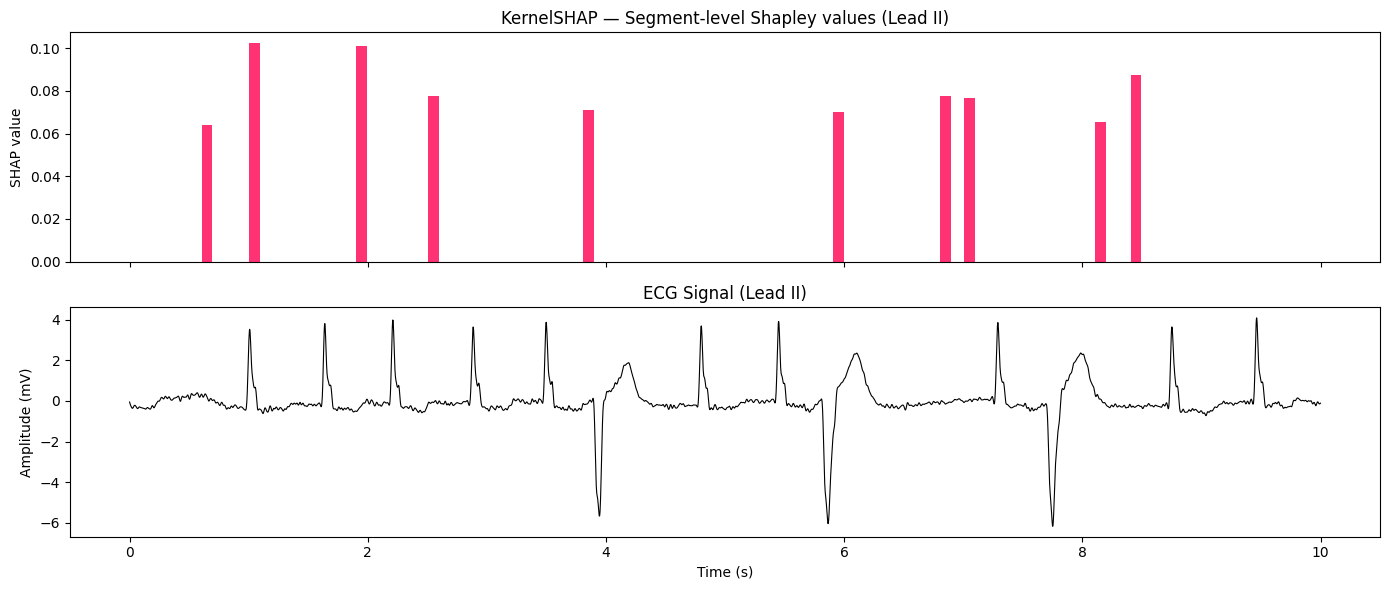

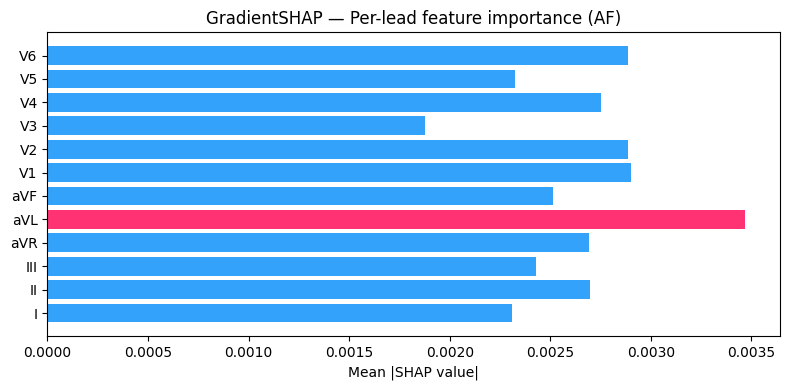

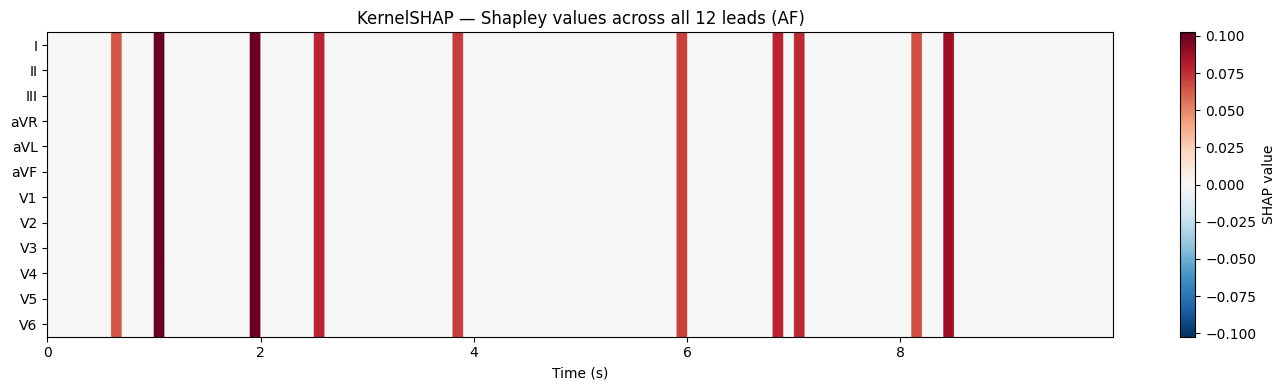

In [5]:
import shap
import matplotlib.pyplot as plt

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
time_axis = np.arange(signal.shape[-1]) / FS

# --- KernelSHAP: segment-level bar plot ---
ks_n_seg = xai_cfg['methods']['kernel_shap']['n_segments']
seg_size = signal.shape[-1] // ks_n_seg
# Average KernelSHAP values per segment for Lead II
ks_lead2 = ks_attr[1]  # [5000]
seg_vals = np.array([ks_lead2[i*seg_size:(i+1)*seg_size].mean() for i in range(ks_n_seg)])
seg_times = np.array([(i + 0.5) * seg_size / FS for i in range(ks_n_seg)])

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].bar(seg_times, seg_vals, width=seg_size / FS * 0.9,
            color=np.where(seg_vals >= 0, '#ff0051', '#008bfb'), alpha=0.8)
axes[0].set_ylabel('SHAP value')
axes[0].set_title('KernelSHAP — Segment-level Shapley values (Lead II)')
axes[0].axhline(0, color='grey', linewidth=0.5)

axes[1].plot(time_axis, signal[0, 1, :].numpy(), color='black', linewidth=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_title('ECG Signal (Lead II)')
plt.tight_layout()
plt.show()

# --- GradientSHAP: bar plot of mean |SHAP value| per lead ---
gs_lead_importance = np.abs(gs_attr).mean(axis=1)  # [12] — mean |attr| per lead
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#ff0051' if v == gs_lead_importance.max() else '#008bfb' for v in gs_lead_importance]
ax.barh(lead_names, gs_lead_importance, color=colors, alpha=0.8)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('GradientSHAP — Per-lead feature importance (AF)')
plt.tight_layout()
plt.show()

# --- SHAP heatmap-style plot: all 12 leads × time for KernelSHAP ---
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(ks_attr, aspect='auto', cmap='RdBu_r',
               extent=[0, time_axis[-1], 11.5, -0.5],
               vmin=-np.abs(ks_attr).max(), vmax=np.abs(ks_attr).max())
ax.set_yticks(range(12))
ax.set_yticklabels(lead_names)
ax.set_xlabel('Time (s)')
ax.set_title('KernelSHAP — Shapley values across all 12 leads (AF)')
plt.colorbar(im, ax=ax, label='SHAP value')
plt.tight_layout()
plt.show()

## Method comparison — Lead II attribution overlay

All four methods are compared on **Lead II**, the standard monitoring lead in clinical practice. Lead II typically shows the clearest P-waves, QRS complexes, and T-waves, making it the most intuitive lead for visual validation of attribution maps.

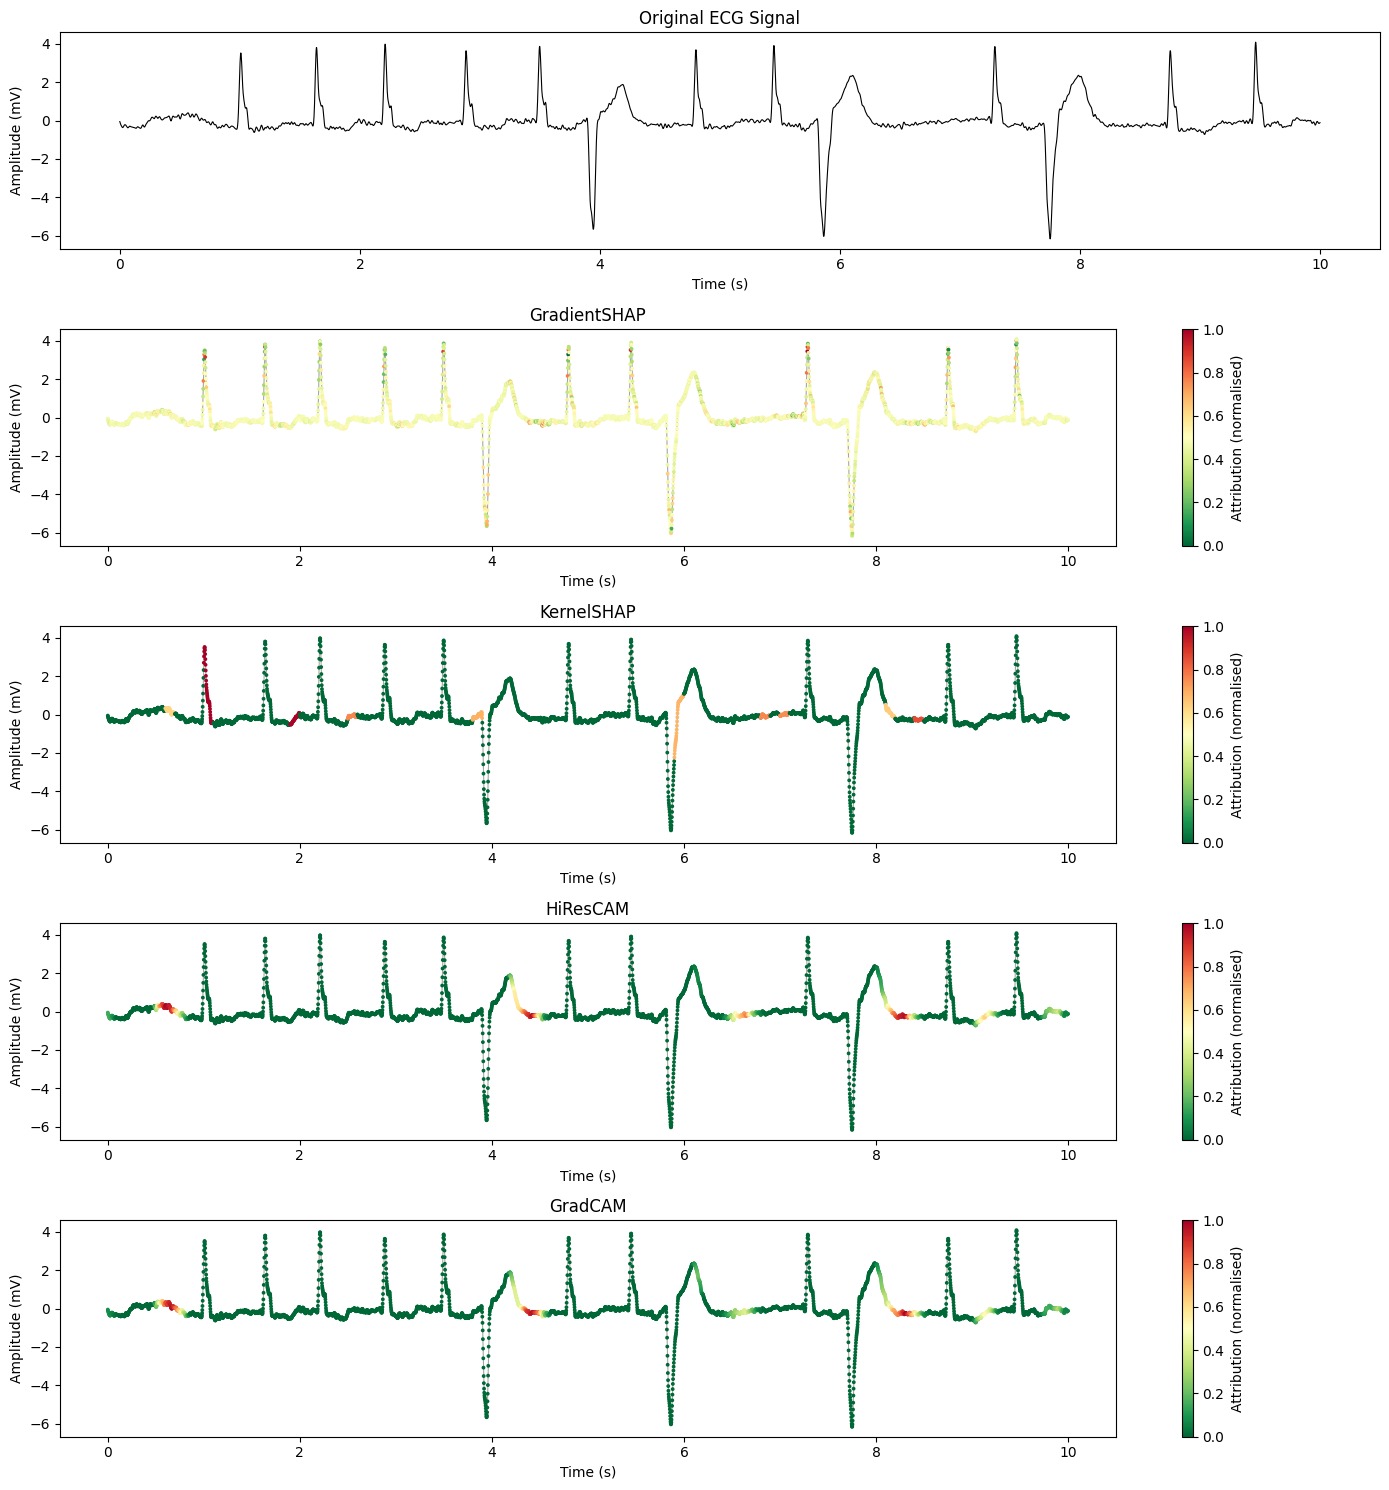

In [6]:
# For multi-lead Captum attributions, use Lead II (index 1) to match plot_method_comparison's
# expected 1D input.  For CAM methods the output is already 1D.
lead2 = signal[0, 1, :].numpy()   # Lead II, shape [1000]

attributions = {
    'GradientSHAP': gs_attr[1],
    'KernelSHAP': ks_attr[1],
    'HiResCAM': hrc_attr,
    'GradCAM': gc_attr,
}

plot_method_comparison(lead2, attributions, fs=float(FS))


## Faithfulness evaluation — AOPC ranking and deletion curves

Faithfulness measures whether the features an XAI method considers important are *actually* important to the model:

- **Deletion curves** progressively remove the most important features (replace with zeros) and track the confidence drop — a steeper drop means the method identified truly important features.
- **Insertion curves** do the reverse: progressively *add* the most important features to a blank signal.
- **AOPC** (Area Over the Perturbation Curve) summarises each curve into a single score for easy method ranking.
- A **random baseline** provides a lower bound — any useful XAI method should outperform random feature ordering.

Original confidence: 0.7961

Method                      Deletion AOPC  Insertion AOPC
---------------------------------------------------------
KernelSHAP                         0.5814          0.2947
GradCAM                            0.5355          0.2488
HiResCAM                           0.5209          0.2536
Random                             0.4928          0.3213
GradientSHAP                       0.3453          0.6569


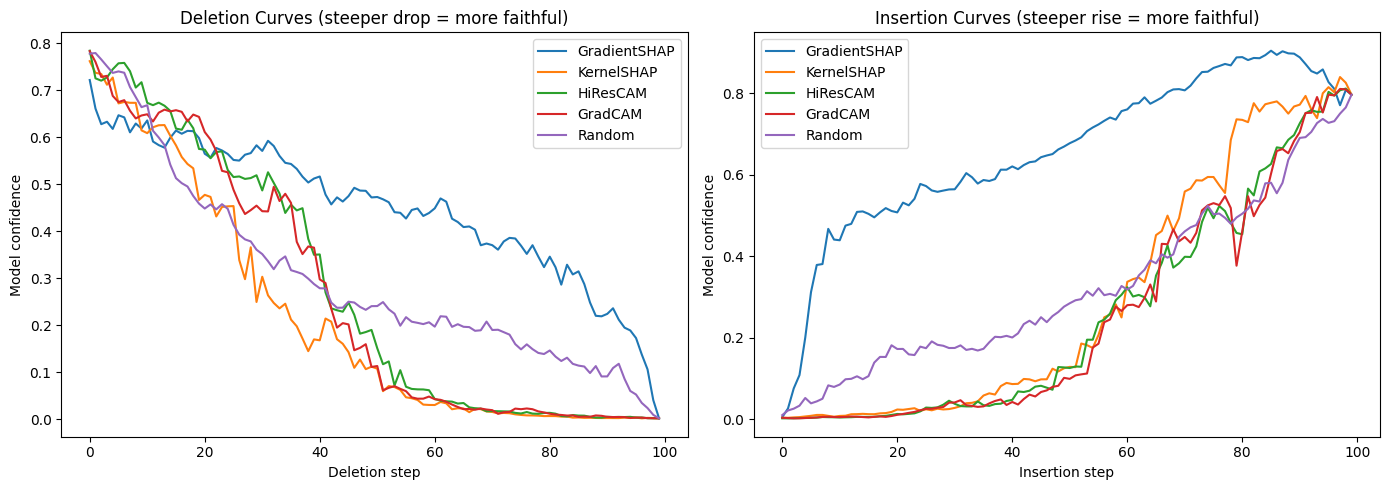

In [7]:
deletion_steps = xai_cfg['evaluation']['deletion_steps']
include_random = xai_cfg['evaluation']['include_random']

# Run AOPC for all methods (deletion + insertion, with random baseline)
aopc_results = compare_methods(
    model, signal, attributions, target_class,
    steps=deletion_steps, include_random=include_random, include_insertion=True,
)

with torch.no_grad():
    conf = torch.sigmoid(model(signal))[0, target_class].item()
    print(f"Original confidence: {conf:.4f}\n")

print(f"{'Method':<25s}  {'Deletion AOPC':>14s}  {'Insertion AOPC':>14s}")
print("-" * 57)
for method, scores in sorted(aopc_results.items(), key=lambda x: -x[1]['deletion_aopc']):
    del_aopc = scores['deletion_aopc']
    ins_aopc = scores['insertion_aopc']
    print(f"{method:<25s}  {del_aopc:>14.4f}  {ins_aopc:>14.4f}")

# Collect full deletion + insertion curves (including Random)
from src.explainability.evaluation import _random_attributions

all_attrs = dict(attributions)
if include_random:
    all_attrs["Random"] = _random_attributions(signal.shape[-1])

del_curves = {}
ins_curves = {}
for name, attr in all_attrs.items():
    del_scores, _ = deletion_curve(model, signal, attr, target_class, steps=deletion_steps)
    ins_scores, _ = insertion_curve(model, signal, attr, target_class, steps=deletion_steps)
    del_curves[name] = del_scores
    ins_curves[name] = ins_scores

plot_faithfulness_curves(del_curves, ins_curves)

## Aggregate faithfulness — AOPC across test samples

Single-sample AOPC results can be noisy — one sample might favour a method by coincidence. Averaging deletion and insertion AOPC over multiple AF-positive test samples gives a more reliable ranking of which XAI method most faithfully reflects the model's decision process.

Aggregating AOPC over 20 samples with target class 'AF'...



Aggregating AOPC: 100%|██████████| 20/20 [26:46<00:00, 80.33s/it]

Method                            deletion_aopc        insertion_aopc
---------------------------------------------------------------------
GradCAM                      0.6415 ± 0.0658      0.3978 ± 0.1138  
HiResCAM                     0.6368 ± 0.0661      0.4047 ± 0.1130  
KernelSHAP                   0.5859 ± 0.0544      0.3420 ± 0.0964  
GradientSHAP                 0.3821 ± 0.1164      0.6725 ± 0.0649  
Random                       0.3643 ± 0.1138      0.5588 ± 0.0937  


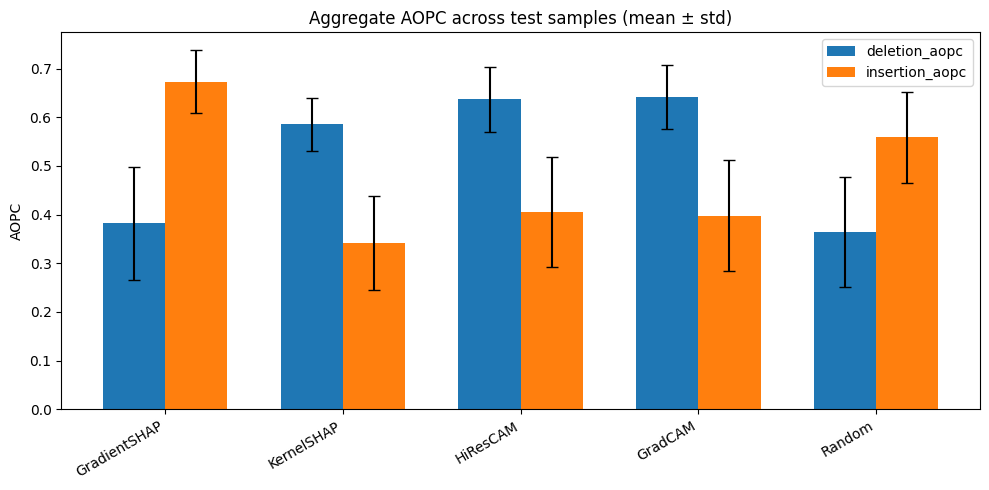

In [8]:
def compute_all_attributions(model, signal, target_class):
    """Compute all 4 XAI methods for a single sample, returning Lead II attributions."""
    background = torch.zeros(20, 12, signal.shape[-1])
    target_layer = get_layer(model, TARGET_LAYER)

    gs = compute_gradient_shap(model, signal, target_class, background,
                               n_samples=xai_cfg['methods']['gradient_shap']['n_samples'])
    ks = compute_kernel_shap(model, signal, target_class, background,
                             n_segments=xai_cfg['methods']['kernel_shap']['n_segments'],
                             nsamples=xai_cfg['methods']['kernel_shap']['nsamples'])
    hrc = compute_hirescam(model, signal, target_layer, target_class)
    gc = compute_gradcam(model, signal, target_layer, target_class)

    return {
        'GradientSHAP': gs[1],   # Lead II
        'KernelSHAP': ks[1],     # Lead II
        'HiResCAM': hrc,
        'GradCAM': gc,
    }


n_agg_samples = xai_cfg['evaluation']['aggregate_n_samples']
print(f"Aggregating AOPC over {n_agg_samples} samples with target class '{target_class_name}'...\n")

agg_summary = aggregate_aopc(
    model, dataset, compute_all_attributions,
    target_class=target_class,
    n_samples=n_agg_samples,
    steps=deletion_steps,
    include_insertion=True,
    include_random=include_random,
    seed=SEED,
)

# Print summary table
metrics = list(next(iter(agg_summary.values())).keys())
header = f"{'Method':<25s}" + "".join(f"  {m:>20s}" for m in metrics)
print(header)
print("-" * len(header))
for method, met_dict in sorted(agg_summary.items(), key=lambda x: -x[1]['deletion_aopc'][0]):
    row = f"{method:<25s}"
    for m in metrics:
        mean, std = met_dict[m]
        row += f"  {mean:>8.4f} ± {std:<8.4f}"
    print(row)

plot_aggregate_aopc(agg_summary)